<a href="https://colab.research.google.com/github/behzadmgr-Fi/Linear-Regression/blob/main/Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Linear Regression Analysis**
This project uses simple linear regression to predict an area's population based on its total number of bedrooms.

**Step 1:**
Install and import the required Python libraries

In [149]:
import pandas as pn
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt

**Step 2:** Read the Dataset AND
df → the full housing dataset, with 20,640 rows and 10 columns.

In [150]:
df = pn.read_csv('/content/drive/MyDrive/housing.csv')

In [151]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**step 3** :
reg_df → a DataFrame containing your two selected variables.

In [152]:
reg_df = df[["population", "total_bedrooms"]].copy()
cdf.head(9)

,population,total_bedrooms
0,322.0,129.0
1,2401.0,1106.0
2,496.0,190.0
3,558.0,235.0
4,565.0,280.0
5,413.0,213.0
6,1094.0,489.0
7,1157.0,687.0
8,1206.0,665.0


**In Step 4**, we use df.info() to examine the dataset structure, column data types, and missing values.(total_bedrooms) 20,433 values, with 207 missing values and its not too much

In [153]:
reg_def.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   population      20433 non-null  float64
 1   total_bedrooms  20433 non-null  float64
dtypes: float64(2)
memory usage: 478.9 KB


**In Step 5**, the regression model cannot be trained on rows where the target value is missing.

In [154]:
reg_def = df[["population", "total_bedrooms"]].dropna()
reg_def.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   population      20433 non-null  float64
 1   total_bedrooms  20433 non-null  float64
dtypes: float64(2)
memory usage: 478.9 KB


**Step 6,** Calculate the Correlation

In [155]:
corr_matrix=reg_df.corr()
corr_matrix

,population,total_bedrooms
population,1.000000,0.877747
total_bedrooms,0.877747,1.000000


**Step 7**, I use a scatter plot to visualize the relationship between total bedrooms and population. The upward pattern indicates a positive relationship, although some outliers and increasing variability can also be observed.

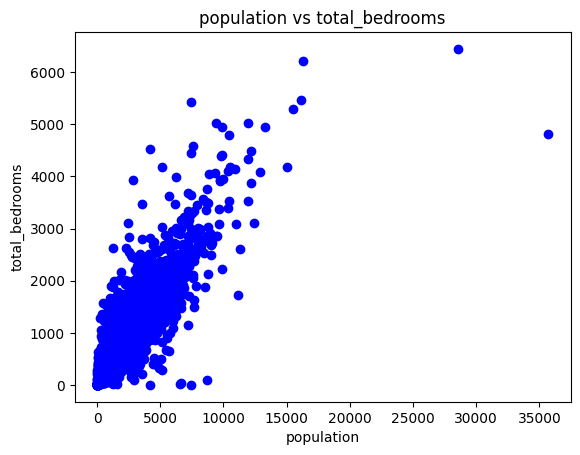

In [156]:
plt.scatter(reg_def.population,reg_def.total_bedrooms, color='blue')
plt.xlabel('population')
plt.ylabel('total_bedrooms')
plt.title('population vs total_bedrooms')
plt.show()

There are some miss value in total_bedrooms we can use median as missed values

**Step** **8**: Define the Feature and Target



In [157]:
X = reg_def[["total_bedrooms"]]
y = reg_def["population"]

**Step 8,** Split the data. The dataset was divided into 80% training data and 20% testing data. A fixed random state was used to make the split reproducible.

In [158]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Step** **9**, check the shape. This confirms that each feature set has the same number of observations as its corresponding target set.

In [159]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16346, 1)
X_test: (4087, 1)
y_train: (16346,)
y_test: (4087,)


**Step 10**, Import Linear Regression



In [160]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

***Step 11*** , *See* the intercept and coefficient

In [161]:
print("Intercept:", lin_reg.intercept_)
print("Coefficient:", lin_reg.coef_[0])

Intercept: 155.67604146580652
Coefficient: 2.3596598450424455


**Step 12**,
Predicted Total Bedrooms =
Intercept
+
Coefficient × Population

In [167]:
y_pred = lin_reg.predict(X_test)
print(y_pred[:10])

[ 811.66147839 2789.05642853 2168.46588929  806.9421587  1564.39296896
  601.65175218 1486.52419407 1097.18031964  979.19732739  873.01263436]


**Step 13**,Use RMSE , MSE and R2 The linear regression model achieved an R² score of approximately 0.808, indicating that total bedrooms explain about 80.8% of the variation in population. The model obtained an RMSE of approximately 503.59, meaning that its population predictions typically differ from the actual values by about 504 people.

In [170]:
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("R²:", r2)

print("MSE:", mse)
print("RMSE:", rmse)

R²: 0.8076491567474937
MSE: 253605.8159435044
RMSE: 503.5929069630592


**Step 14,** The scatter plot shows the actual population values, while the red regression line represents the population predicted from total bedrooms. The upward trend indicates a strong positive relationship between the two variables.

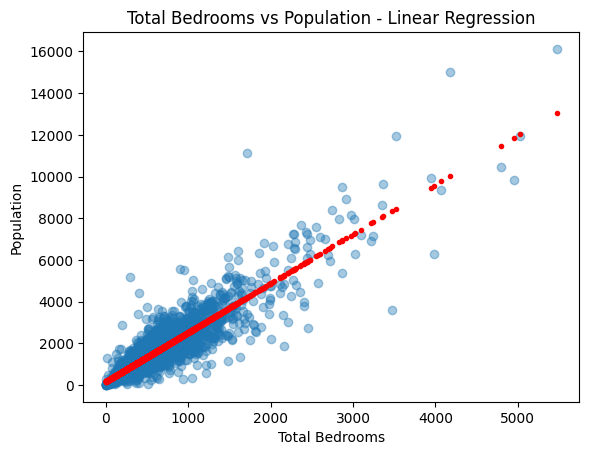

In [168]:
import matplotlib.pyplot as plt

plt.scatter(
    X_test["total_bedrooms"],
    y_test,
    alpha=0.4
)

plt.plot(
    X_test["total_bedrooms"],
    y_pred,
    "r."
)

plt.xlabel("Total Bedrooms")
plt.ylabel("Population")
plt.title("Total Bedrooms vs Population - Linear Regression")

plt.show()